**What are you trying to do in this notebook?**

The Spaceship titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on it's maiden voyage transporting immigrants from our solar system to three new habitable exoplanets orbiting nearby stars.

My task is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spaceship anomaly.

There is a information about dataset :-

**PassengerId** - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

**HomePlanet** - The planet the passenger departed from, typically their planet of permanent residence.

**CryoSleep** - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

**Cabin** - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.

**Destination** - The planet the passenger will be debarking to.

**Age** - The age of the passenger.

**VIP** - Whether the passenger has paid for special VIP service during the voyage.

**RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.

**Name** - The first and last names of the passenger.

**Transported** - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.



**Why are you trying it?**

To help rescue crews and retrieve the lost passengers and to predict where passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

Help, save them and change history!

My observations are -

* 8693 rows(obervations) and 14 columns(13 features + 1 target varible)
* data types -int,float,obj
* Notice - we have some feature which have multiple informations in one column and this are also have the greatest cardinality
* we also some missing values
* we haveBinary columns- Transported,CryoSleep,VIP
* high cardinality in columns

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
import numpy as np 
import pandas as pd

In [3]:
import plotly.express as px

In [4]:
titanic=pd.read_csv("../input/spaceship-titanic/train.csv")

In [5]:
titanic_test=pd.read_csv("../input/spaceship-titanic/test.csv")

In [6]:
titanic.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [7]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


<AxesSubplot:title={'center':'Cardinality in our columns'}>

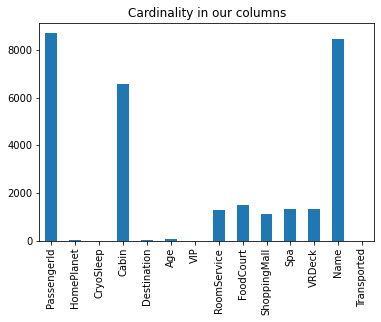

In [8]:
titanic.nunique().plot.bar(title="Cardinality in our columns")

In [9]:
print(f'Duplicates in train set: {titanic.duplicated().sum()}, ({np.round(100*titanic.duplicated().sum()/len(titanic),1)}%)')

Duplicates in train set: 0, (0.0%)


In [10]:
print(f'Duplicates in test set: {titanic_test.duplicated().sum()}, ({np.round(100*titanic_test.duplicated().sum()/len(titanic_test),1)}%)')

Duplicates in test set: 0, (0.0%)


In [11]:
titanic[["Passenger_group","Passennger_no._in_group"]]=titanic["PassengerId"].str.split("_",expand=True)

In [12]:
titanic.drop(columns=["PassengerId"],inplace=True)

In [13]:
titanic.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Passenger_group,Passennger_no._in_group
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,01


In [14]:
titanic[["Cabin_deck","Cabin_no.","Cabin_side"]]=titanic["Cabin"].str.split("/",expand=True)

In [15]:
titanic.drop(columns=["Cabin"],inplace=True)

In [16]:
titanic.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Passenger_group,Passennger_no._in_group,Cabin_deck,Cabin_no.,Cabin_side
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01,B,0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01,F,0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01,A,0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02,A,0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,01,F,1,S


In [17]:
titanic[["firstname","last_name"]]=titanic["Name"].str.split(" ",expand=True)

In [18]:
titanic.drop(columns=["Name"],inplace=True)

In [19]:
titanic.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Passenger_group,Passennger_no._in_group,Cabin_deck,Cabin_no.,Cabin_side,firstname,last_name
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0001,01,B,0,P,Maham,Ofracculy
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,0002,01,F,0,S,Juanna,Vines
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,0003,01,A,0,S,Altark,Susent
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,0003,02,A,0,S,Solam,Susent
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,0004,01,F,1,S,Willy,Santantines


In [20]:
titanic.nunique()

HomePlanet                    3
CryoSleep                     2
Destination                   3
Age                          80
VIP                           2
RoomService                1273
FoodCourt                  1507
ShoppingMall               1115
Spa                        1327
VRDeck                     1306
Transported                   2
Passenger_group            6217
Passennger_no._in_group       8
Cabin_deck                    8
Cabin_no.                  1817
Cabin_side                    2
firstname                  2706
last_name                  2217
dtype: int64

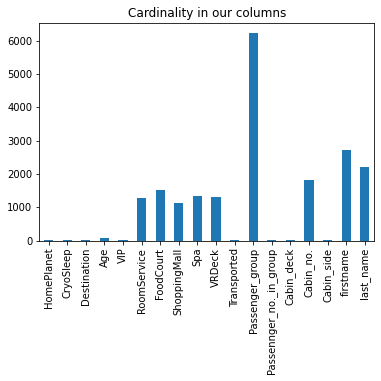

In [21]:
titanic.nunique().plot.bar(title="Cardinality in our columns");

In [22]:
missing=(titanic.isnull().mean().sort_values(ascending=False)*100).reset_index()
missing.rename(columns={0:"Average"},inplace=True)
missing.head()

fig=px.histogram(missing,x="Average",y="index",title="<b>% of Missing values",color="index",labels={"Average":"%age of missing values","index":"Column Names"})
fig.update_layout(
    font_color="white",
    font_size=12,
    title_font_color="cyan",
    legend_title_font_color="white",
    legend_title_font_size=20,
    template="plotly_dark",
    title_font_size=30
    
)
fig.update_layout(xaxis_title = "<b>Amount in %age",xaxis_title_font_size=20,
                  yaxis_title="<b>Column-Name",yaxis_title_font_size=20,title_x=0.5)
fig.show()
fig=px.imshow(titanic.isnull().T,color_continuous_scale=px.colors.sequential.Electric,title="<b>Missing values in our data",)
fig.update_layout(template="plotly_dark",title_font_size=30,title_x=0.5)


fig.show()

In [23]:
(titanic.dropna().shape[0]/titanic.shape[0]) *100

75.99217761417232

In [24]:
titanic["Transported"]=np.where(titanic["Transported"]==True,1,0)

In [25]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   HomePlanet               8492 non-null   object 
 1   CryoSleep                8476 non-null   object 
 2   Destination              8511 non-null   object 
 3   Age                      8514 non-null   float64
 4   VIP                      8490 non-null   object 
 5   RoomService              8512 non-null   float64
 6   FoodCourt                8510 non-null   float64
 7   ShoppingMall             8485 non-null   float64
 8   Spa                      8510 non-null   float64
 9   VRDeck                   8505 non-null   float64
 10  Transported              8693 non-null   int64  
 11  Passenger_group          8693 non-null   object 
 12  Passennger_no._in_group  8693 non-null   object 
 13  Cabin_deck               8494 non-null   object 
 14  Cabin_no.               

In [26]:
titanic.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Passenger_group,Passennger_no._in_group,Cabin_deck,Cabin_no.,Cabin_side,firstname,last_name
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0,0001,01,B,0,P,Maham,Ofracculy
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,0002,01,F,0,S,Juanna,Vines
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0,0003,01,A,0,S,Altark,Susent
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0,0003,02,A,0,S,Solam,Susent
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,0004,01,F,1,S,Willy,Santantines


In [27]:
numerical_cols=["Age","RoomService","Spa","VRDeck","ShoppingMall","FoodCourt"]
numerical_cols

['Age', 'RoomService', 'Spa', 'VRDeck', 'ShoppingMall', 'FoodCourt']

In [28]:
categorical_cols=[feature for feature in titanic.columns if feature not in numerical_cols]
categorical_cols

['HomePlanet',
 'CryoSleep',
 'Destination',
 'VIP',
 'Transported',
 'Passenger_group',
 'Passennger_no._in_group',
 'Cabin_deck',
 'Cabin_no.',
 'Cabin_side',
 'firstname',
 'last_name']

In [29]:
for feature in categorical_cols:
    if feature not in['Passenger_group','firstname','last_name','Cabin_no.']:

        df=titanic[feature].value_counts().reset_index()
        
        fig=px.pie(df,values=df.columns[1],names=df.columns[0],
                   labels={"index":"<b>"+feature,feature:"Count"},
                  color_discrete_sequence=px.colors.qualitative.Pastel)

        fig.update_layout(title="<b>"+feature, title_font_size=30,
                         font_size=20,
                         title_x=0.5,legend_bordercolor="#000",legend_borderwidth=2,
                         hoverlabel_font_size=20)
        fig.update_traces(marker=dict( line=dict(color='#000000', width=2)))              
        fig.show()

In [30]:
for feature in categorical_cols:
     if feature not in['Passenger_group','firstname','last_name','Cabin_no.',"Transported"]:
        fig=px.histogram(titanic,x=feature,facet_col="Transported",color="Transported",color_discrete_sequence=px.colors.qualitative.Alphabet_r)
        fig.update_layout(title="<b>"+feature+" vs Transported", title_font_size=30,
                             font_size=20,
                             title_x=0.5,
                             hoverlabel_font_size=20,template="plotly_dark")
        
        fig.show()

In [31]:
for feature in numerical_cols:
    fig=px.violin(titanic,x=feature,color="Transported",title="<b>"+feature+" Distribution",template="plotly_dark" )
    fig.update_layout(hovermode='x',title_font_size=30)
    fig.update_layout(
    title_font_color="#ffff00",
    template="plotly_dark",
    title_font_size=30,
    hoverlabel_font_size=20,
    title_x=0.5
    )
    fig.show()
    
    fig=px.histogram(titanic,x=feature,title="<b>"+feature+"Vs Transported",color="Transported",template="plotly_dark")
    fig.update_layout(hovermode='x',title_font_size=30)
    fig.update_layout(
    title_font_color="#ffff00",
    template="plotly_dark",
    title_font_size=30,
    hoverlabel_font_size=20,
    title_x=0.5)
    
    fig.show()

In [32]:
px.imshow(titanic.corr().round(3),text_auto=True)

In [33]:
px.scatter_matrix(titanic[numerical_cols+["Transported"]],height=800,color="Transported")

In [34]:
fig=px.parallel_coordinates(titanic,color="Transported",title="<b>Multivariate plot for Numerical Data")
fig.update_layout(title_font_size=30,title_x=0.5)

In [35]:
fig=px.imshow(
    pd.crosstab(titanic["Cabin_deck"],titanic["Cabin_side"]).T
    ,text_auto=True,title="No. of people Travelling in (Cabin_DecK,Cabin_side)",
    labels={"color":"<b>No.of people"},color_continuous_scale=px.colors.sequential.haline_r)
fig.update_layout(font_size=15,font_color="#ffcce6",
                 title_font_size=30,title_font_color="Orange",template="plotly_dark")
fig.show()
fig=px.imshow(
    pd.crosstab(titanic["Cabin_deck"],titanic["Cabin_side"],titanic["Transported"],aggfunc="mean").round(3).T
    ,text_auto=True,title="% of people Transported(1) in (Cabin_DecK,Cabin_side)",
    labels={"color":"<b>%Transpoted"},color_continuous_scale=px.colors.sequential.haline_r)
fig.update_layout(font_size=15,font_color="#ffcce6",
                 title_font_size=30,title_font_color="Orange",template="plotly_dark")
fig.show()

In [36]:
fig=px.imshow(
    pd.crosstab(titanic["HomePlanet"],titanic["CryoSleep"]).T
    ,text_auto=True,title="<b>No. of people Travelling in (HomePlanet,Cryosleep)",
    labels={"color":"<b>No.of people"},color_continuous_scale=px.colors.sequential.haline_r)
fig.update_layout(font_size=15,font_color="#ffcce6",
                 title_font_size=30,title_font_color="Orange",template="plotly_dark")
fig.show()
fig=px.imshow(
    pd.crosstab(titanic["HomePlanet"],titanic["CryoSleep"],titanic["Transported"],aggfunc="mean").round(3).T
    ,text_auto=True,title="<b>No. of people Travelling in (HomePlanet,Cryosleep)",
    labels={"color":"<b>%Transpoted"},color_continuous_scale=px.colors.sequential.haline_r)
fig.update_layout(font_size=15,font_color="#ffcce6",
                 title_font_size=30,title_font_color="Orange",template="plotly_dark")
fig.show()

In [37]:
titanic[(titanic["HomePlanet"]=="Europa") & (titanic["CryoSleep"]==False)]["Transported"].mean()

0.40017211703958694

In [38]:
fig=px.parallel_categories(titanic,color="Transported",
                           title="<b>Multivarite Plot For Categorical data",height=600,width=1000)
fig.update_layout(title_font_size=30,title_x=0.5)

**Did it work?**

My oservations are -

**Homeplanet**- most people was from Earth Followed by Europa, Mars

**Cryosleep** - most people was not in CryoSleep

**Destination** - mostly people was debarking to TRAPPIST-1e Followed by Canri e, PSO

**Vip** - frequency of non VIP people quite large Compared VIP people

**Transported** - no. of non transported is greater than transported people

**No.inGroup** - Majority of the were travellling alone in their group

* Cabin Name- majority of people were in G and F cabin .

* Cabin side-- NO of people on both sides is almost equal

**What did you not understand about it?**

Well, everything provides in the competition data page. I've no problem while working on it. If you guys don't understand the thing that I'll do in this notebook then please comment on this notebook.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

**I Hope you find this notebook useful , Good Luck!**
